# PEMS Preprocessing with Positional Embeddings

This notebook documents the preprocessing pipeline that: 
- reads raw PEMS files (read-only),
- adds time-of-day and day-of-week scaled features,
- optionally computes patch spatio-temporal sinusoidal positional embeddings,
- builds rolling-window datasets with inputs shaped (N_samples, WINDOW=12, N_nodes, channels) and targets shaped (N_samples, HORIZON=12, N_nodes, 1),
- saves results into three folders (Flow, Speed, Occupancy) without deleting any existing files.

**Assumptions:** 5-minute intervals → 288 steps/day. Window=12 (1 hour), Horizon=12 (1 hour).  


In [21]:
# Section 1: Setup imports and constants
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

WINDOW = 12
HORIZON = 12
FREQ_PER_DAY = 288

# Set OUT_ROOT to the workspace absolute data path
OUT_ROOT = Path('/home/jatin/contrast/ST-SSL/data')
if not OUT_ROOT.exists():
    # fallback: try relative lookup
    OUT_ROOT = Path('ST-SSL/data') if Path('ST-SSL/data').exists() else Path('data')

RAW_ROOT = OUT_ROOT / 'raw'
if not RAW_ROOT.exists():
    # fallback
    RAW_ROOT = OUT_ROOT

print('Notebook constants set. CWD:', Path.cwd())
print('Resolved OUT_ROOT:', OUT_ROOT)
print('Resolved RAW_ROOT:', RAW_ROOT)


Notebook constants set. CWD: /home/jatin/contrast/ST-SSL/notebook
Resolved OUT_ROOT: /home/jatin/contrast/ST-SSL/data
Resolved RAW_ROOT: /home/jatin/contrast/ST-SSL/data/raw


In [23]:
# Section 2: Locate raw files and inspect
for ds in ['PEMS08', 'PEMS04']:
    # Look for a single consolidated npz first in RAW_ROOT and OUT_ROOT
    candidates = [RAW_ROOT / ds / f"{ds}.npz", OUT_ROOT / ds / f"{ds}.npz"]
    found = False
    for p in candidates:
        if p.exists():
            arr = np.load(p)
            print(ds, 'found at', p, ' keys:', list(arr.keys()))
            if 'data' in arr:
                print('Data shape:', arr['data'].shape, '(T, N, C)')
            found = True
            break
    if found:
        continue
    # Fallback: check for processed folders (train/val/test) or POS dirs
    proc_dir = OUT_ROOT / ds
    pos_dirs = list(OUT_ROOT.glob(f"{ds}*POS*")) if OUT_ROOT.exists() else []
    if proc_dir.exists():
        print(f"{ds} consolidated file not found; found processed directory:", proc_dir)
        print('Contents:', [p.name for p in proc_dir.iterdir()])
    elif pos_dirs:
        print(f"{ds} consolidated file not found; found POS directories:", [str(p) for p in pos_dirs])
    else:
        if OUT_ROOT.exists():
            print(f"{ds} not found in expected locations. Available dirs under {OUT_ROOT}:", [p.name for p in OUT_ROOT.iterdir() if p.is_dir()][:40])
        else:
            print(f"{ds} not found and OUT_ROOT {OUT_ROOT} does not exist; cwd: {Path.cwd()}")

# Example: try to inspect an existing processed POS train if present
p = OUT_ROOT / 'PEMS08_Flow_POS' / 'train.npz'
if p.exists():
    arr = np.load(p)
    print('Loaded processed PEMS08 Flow POS train keys:', list(arr.keys()))
    print('train x shape:', arr['x'].shape)
else:
    print('No processed PEMS08 POS train file found at', p)


PEMS08 found at /home/jatin/contrast/ST-SSL/data/raw/PEMS08/PEMS08.npz  keys: ['data']
Data shape: (17856, 170, 3) (T, N, C)
PEMS04 found at /home/jatin/contrast/ST-SSL/data/raw/PEMS04/PEMS04.npz  keys: ['data']
Data shape: (16992, 307, 3) (T, N, C)
Loaded processed PEMS08 Flow POS train keys: ['x', 'y']
train x shape: (10699, 12, 170, 3)


In [27]:
# Section 3: Create and run preprocessing script (already available at data/preprocess_positional.py)
from importlib import reload
import sys
from pathlib import Path
# Ensure project package path is on sys.path
proj_root = Path('/home/jatin/contrast/ST-SSL')
if str(proj_root) not in sys.path:
    sys.path.append(str(proj_root))

import data.preprocess_positional as pp
reload(pp)

print('preprocess_positional module loaded. Function available: build_dataset_for_dim')

# Example: show how to call it for PEMS08 Flow (no patch / 3-channel)
raw = np.load(RAW_ROOT / 'PEMS08' / 'PEMS08.npz')
data08 = raw['data']
print('PEMS08 data shape:', data08.shape)

# Run the builder for PEMS08 Flow into data/PEMS08_Flow_POS (this is non-destructive)
pp.build_dataset_for_dim(data08, dim_idx=0, output_dir=str(OUT_ROOT / 'PEMS08_Flow_POS'), window_size=WINDOW, horizon=HORIZON, patch=False)
print('\nSaved datasets to', OUT_ROOT / 'PEMS08_Flow_POS', '(train/val/test + meta)')


preprocess_positional module loaded. Function available: build_dataset_for_dim
PEMS08 data shape: (17856, 170, 3)
Building dataset /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS: T=17856, N=170, dim=0
  Created X (17833, 12, 170, 3) and Y (17833, 12, 170, 1)
  Saved train /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS/train.npz - x:(10699, 12, 170, 3) y:(10699, 12, 170, 1)
  Saved val /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS/val.npz - x:(3566, 12, 170, 3) y:(3566, 12, 170, 1)
  Saved test /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS/test.npz - x:(3568, 12, 170, 3) y:(3568, 12, 170, 1)
  Saved meta to /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS/meta.npz

Saved datasets to /home/jatin/contrast/ST-SSL/data/PEMS08_Flow_POS (train/val/test + meta)


In [33]:
# Section 4: Load a sample processed train file and inspect shapes
npz = np.load(OUT_ROOT / 'PEMS08_Flow_POS' / 'train.npz')
x = npz['x']
y = npz['y']
print('train x shape:', x.shape)  # (samples, 12, N, channels)
print('train y shape:', y.shape)  # (samples, 12, N, 1)

# Show metadata
meta = np.load(OUT_ROOT / 'PEMS08_Flow_POS' / 'meta.npz', allow_pickle=True)
print('meta keys:', meta.files)
for k in meta.files:
    print(k, '->', meta[k])


train x shape: (10699, 12, 170, 3)
train y shape: (10699, 12, 170, 1)
meta keys: ['window_size', 'horizon', 'channels', 'patch', 'patch_D']
window_size -> 12
horizon -> 12
channels -> 3
patch -> False
patch_D -> None


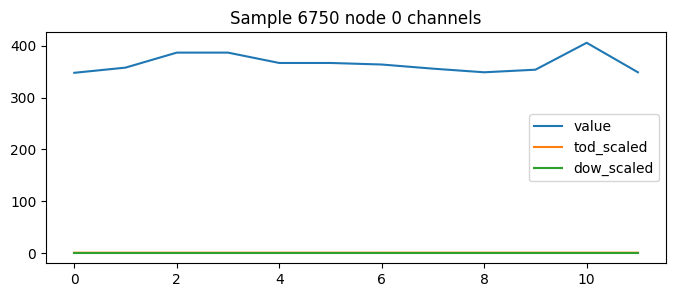

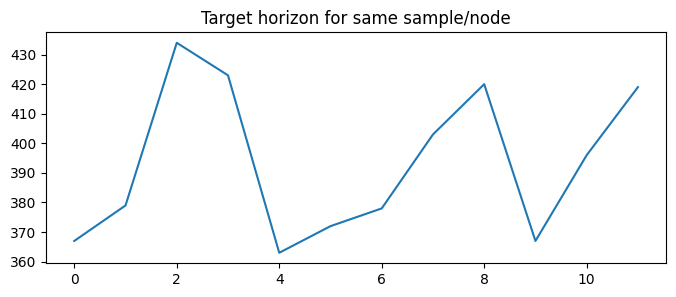

In [36]:
# Section 5: Visualize channels for a sample window and a node
import matplotlib.pyplot as plt
samp = 6750
node = 0
window_vals = x[samp, :, node, 0]
window_tod = x[samp, :, node, 1]
window_dow = x[samp, :, node, 2]

plt.figure(figsize=(8,3))
plt.plot(window_vals, label='value')
plt.plot(window_tod, label='tod_scaled')
plt.plot(window_dow, label='dow_scaled')
plt.legend(); plt.title(f'Sample {samp} node {node} channels')
plt.show()

# Show a single target horizon
plt.figure(figsize=(8,3))
plt.plot(y[samp, :, node, 0], label='target (horizon 12)')
plt.title('Target horizon for same sample/node')
plt.show()


## Notes and How to reproduce

- The script used: `data/preprocess_positional.py` contains the implementation and CLI.  
- Default configs used in this notebook: WINDOW=12, HORIZON=12, no patch PE by default (3-channel input).  
- To generate the optional patch spatiotemporal encoding, run:  
  `python data/preprocess_positional.py --dataset PEMS08 --window 12 --horizon 12 --patch --patch_D 8`

> All saved outputs are under `data/PEMSXX_<Dim>_POS/` and do not delete or modify any existing repository files.


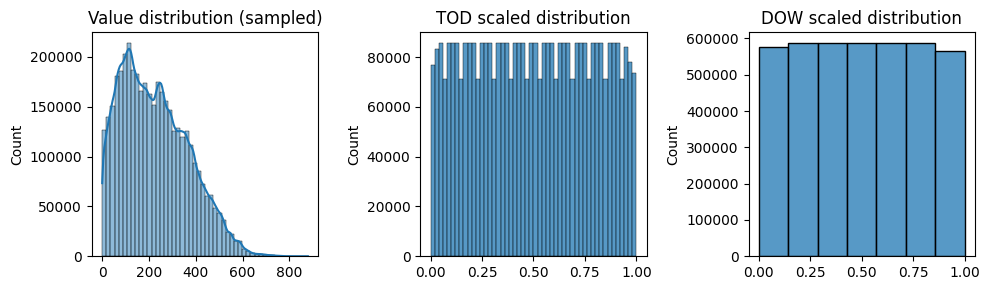

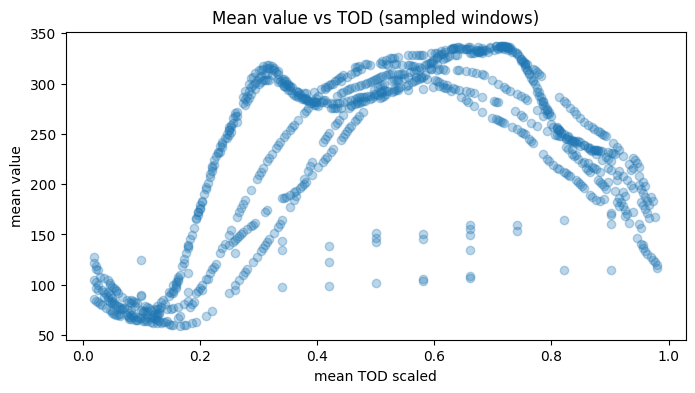

t-SNE on features shape: (2000, 3)


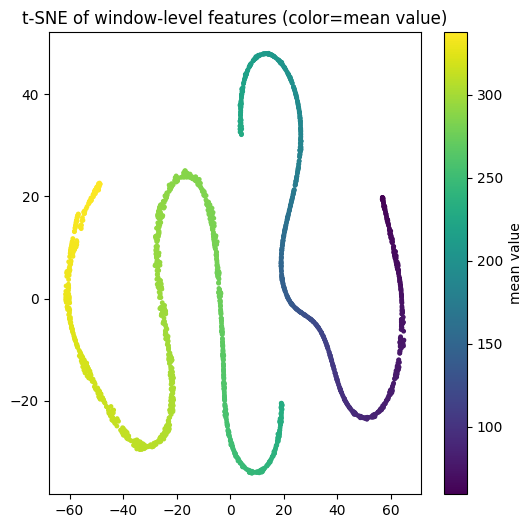

In [39]:
# Section 6: Additional visualizations — distribution, correlations, and t-SNE
from sklearn.manifold import TSNE
import seaborn as sns

# Quick distributions of TOD and DOW channels
sample_x = x[:2000]  # samples x window x N x channels
# Flatten to combine samples/windows/nodes
vals = sample_x[..., 0].ravel()
tod = sample_x[..., 1].ravel()
dow = sample_x[..., 2].ravel()

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
sns.histplot(vals, bins=50, kde=True)
plt.title('Value distribution (sampled)')
plt.subplot(1,3,2)
sns.histplot(tod, bins=50)
plt.title('TOD scaled distribution')
plt.subplot(1,3,3)
sns.histplot(dow, bins=7)
plt.title('DOW scaled distribution')
plt.tight_layout()
plt.show()

# Correlation between channels (value vs TOD/DOW) for random subset of node windows
rand_idx = np.random.choice(sample_x.shape[0], size=1000, replace=False)
vals_samp = sample_x[rand_idx, :, :, 0].reshape(1000, -1).mean(axis=1)
tod_samp = sample_x[rand_idx, :, :, 1].reshape(1000, -1).mean(axis=1)
dow_samp = sample_x[rand_idx, :, :, 2].reshape(1000, -1).mean(axis=1)

plt.figure(figsize=(8,4))
plt.scatter(tod_samp, vals_samp, alpha=0.3)
plt.xlabel('mean TOD scaled')
plt.ylabel('mean value')
plt.title('Mean value vs TOD (sampled windows)')
plt.show()

# t-SNE on flattened window features (value + tod + dow) for 2000 windows
# Reduce each sample-window-node to aggregated features: mean over window and nodes
feat = sample_x.mean(axis=1).mean(axis=1)[:2000]  # shape (2000, channels)
print('t-SNE on features shape:', feat.shape)

ts = TSNE(n_components=2, random_state=42, perplexity=30)
ts_emb = ts.fit_transform(feat)

plt.figure(figsize=(6,6))
plt.scatter(ts_emb[:,0], ts_emb[:,1], c=feat[:,0], cmap='viridis', s=6)
plt.colorbar(label='mean value')
plt.title('t-SNE of window-level features (color=mean value)')
plt.show()


## Section 7: Deep Dive into TOD & DOW Positional Embeddings

The **Time-of-Day (TOD)** and **Day-of-Week (DOW)** embeddings encode temporal periodicity:
- **TOD**: Scaled from `[0, 287]` → `[0, 1]` representing 5-minute intervals across a day
- **DOW**: Scaled from `[0, 6]` → `[0, 1]` representing Monday–Sunday

These embeddings help the model learn:
1. **Daily patterns** (rush hour peaks, overnight lulls)
2. **Weekly patterns** (weekday vs weekend behavior)

Below we visualize these embeddings using t-SNE to see how windows cluster by temporal context.

TOD features shape: (3000, 12)


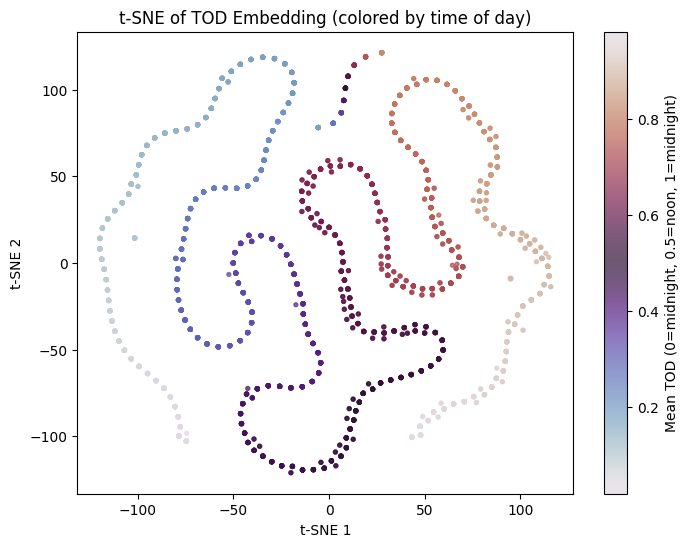

In [40]:
# Section 7a: t-SNE on TOD embedding alone
# Extract TOD values for subset of windows (mean over nodes per window step)
sample_x = x[:3000]
tod_features = sample_x[:, :, :, 1].mean(axis=2)  # (3000, 12) - mean TOD across nodes per timestep
print('TOD features shape:', tod_features.shape)

ts_tod = TSNE(n_components=2, random_state=42, perplexity=40)
tod_emb = ts_tod.fit_transform(tod_features)

# Color by the mean TOD value (proxy for time of day)
mean_tod = tod_features.mean(axis=1)

plt.figure(figsize=(8,6))
sc = plt.scatter(tod_emb[:,0], tod_emb[:,1], c=mean_tod, cmap='twilight', s=8, alpha=0.7)
plt.colorbar(sc, label='Mean TOD (0=midnight, 0.5=noon, 1=midnight)')
plt.title('t-SNE of TOD Embedding (colored by time of day)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.show()

# Interpret: Windows from similar times of day should cluster together

DOW features shape: (3000, 12)


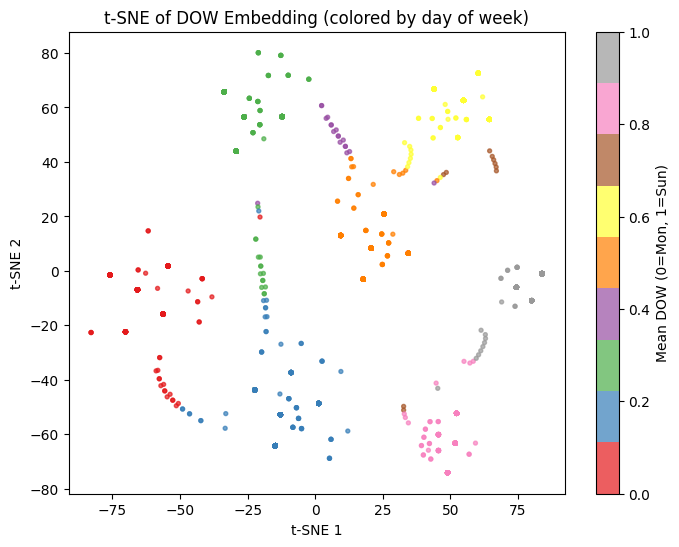

In [41]:
# Section 7b: t-SNE on DOW embedding alone
dow_features = sample_x[:, :, :, 2].mean(axis=2)  # (3000, 12) - mean DOW across nodes per timestep
print('DOW features shape:', dow_features.shape)

ts_dow = TSNE(n_components=2, random_state=42, perplexity=40)
dow_emb = ts_dow.fit_transform(dow_features)

# Color by the mean DOW value
mean_dow = dow_features.mean(axis=1)

plt.figure(figsize=(8,6))
sc = plt.scatter(dow_emb[:,0], dow_emb[:,1], c=mean_dow, cmap='Set1', s=8, alpha=0.7)
plt.colorbar(sc, label='Mean DOW (0=Mon, 1=Sun)')
plt.title('t-SNE of DOW Embedding (colored by day of week)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.show()

# Interpret: Weekday vs weekend windows may form distinct clusters

Combined temporal features shape: (3000, 24)


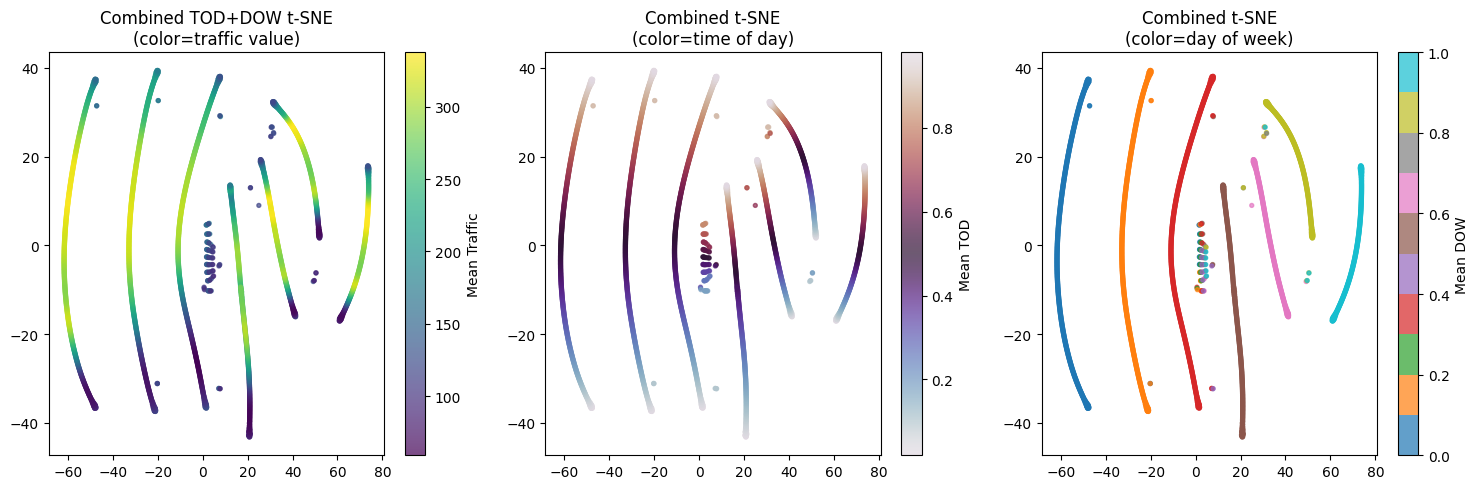

In [42]:
# Section 7c: Combined t-SNE (TOD + DOW) with traffic value overlay
combined_temporal = np.concatenate([tod_features, dow_features], axis=1)  # (3000, 24)
print('Combined temporal features shape:', combined_temporal.shape)

ts_comb = TSNE(n_components=2, random_state=42, perplexity=40)
comb_emb = ts_comb.fit_transform(combined_temporal)

# Color by mean traffic value
mean_val = sample_x[:, :, :, 0].mean(axis=(1,2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: colored by traffic value
sc1 = axes[0].scatter(comb_emb[:,0], comb_emb[:,1], c=mean_val, cmap='viridis', s=8, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], label='Mean Traffic')
axes[0].set_title('Combined TOD+DOW t-SNE\n(color=traffic value)')

# Plot 2: colored by TOD
sc2 = axes[1].scatter(comb_emb[:,0], comb_emb[:,1], c=mean_tod, cmap='twilight', s=8, alpha=0.7)
plt.colorbar(sc2, ax=axes[1], label='Mean TOD')
axes[1].set_title('Combined t-SNE\n(color=time of day)')

# Plot 3: colored by DOW
sc3 = axes[2].scatter(comb_emb[:,0], comb_emb[:,1], c=mean_dow, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(sc3, ax=axes[2], label='Mean DOW')
axes[2].set_title('Combined t-SNE\n(color=day of week)')

plt.tight_layout()
plt.show()

## Section 8: Sinusoidal Spatiotemporal Positional Encoding

For transformer-based models, we can optionally add **patch-level sinusoidal positional encoding** inspired by [Wang and Liu, 2021]:

$$E_{pos}[t, n, 2i] = \sin\left(\frac{t}{10000^{4i/D}}\right)$$
$$E_{pos}[t, n, 2i+1] = \cos\left(\frac{t}{10000^{4i/D}}\right)$$
$$E_{pos}[t, n, 2j+D/2] = \sin\left(\frac{n}{10000^{4j/D}}\right)$$
$$E_{pos}[t, n, 2j+1+D/2] = \cos\left(\frac{n}{10000^{4j/D}}\right)$$

Where:
- $t$ = temporal position (patch index)
- $n$ = spatial position (node index)
- $D$ = embedding dimension
- First half of $D$ encodes **temporal** position, second half encodes **spatial** position

This encoding is **learnable-free** and generalizes to arbitrary sequence lengths.

Positional encoding shape: (12, 20, 16) (T, N, D)


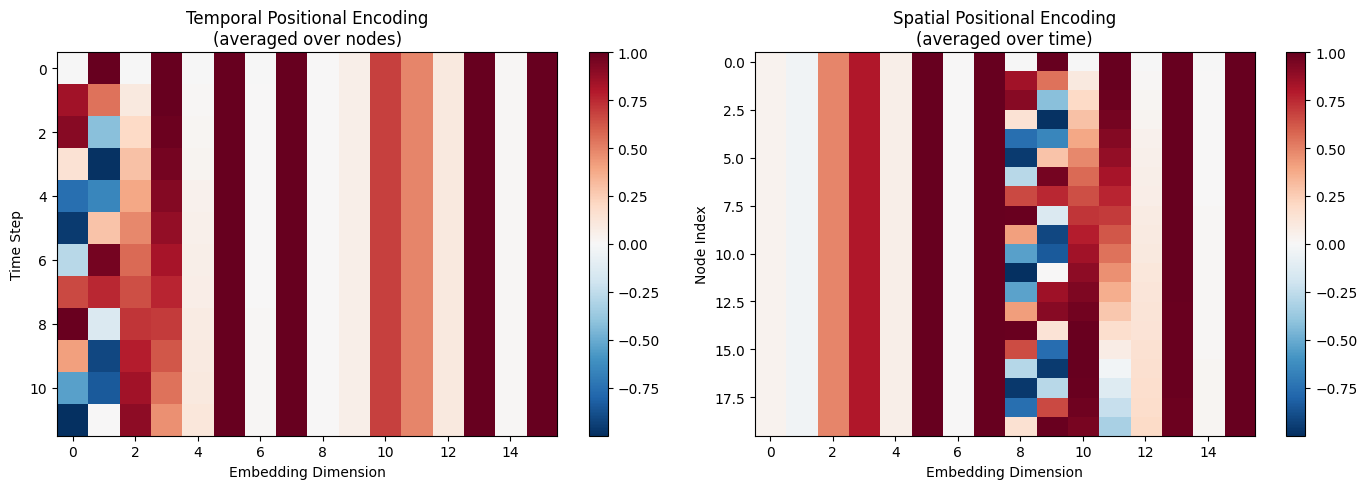

In [43]:
# Section 8a: Visualize sinusoidal positional encoding
def compute_sinusoidal_pe(T, N, D):
    """
    Compute 2D sinusoidal positional encoding.
    First D/2 dims encode temporal position, last D/2 encode spatial position.
    """
    pe = np.zeros((T, N, D))
    
    # Temporal encoding (first half of D)
    for t in range(T):
        for i in range(D // 4):
            denom = 10000 ** (4 * i / D)
            pe[t, :, 2*i] = np.sin(t / denom)
            pe[t, :, 2*i + 1] = np.cos(t / denom)
    
    # Spatial encoding (second half of D)
    for n in range(N):
        for j in range(D // 4):
            denom = 10000 ** (4 * j / D)
            pe[:, n, D//2 + 2*j] = np.sin(n / denom)
            pe[:, n, D//2 + 2*j + 1] = np.cos(n / denom)
    
    return pe

# Example: compute PE for T=12 timesteps, N=20 nodes (subset), D=16 embedding dim
T_demo, N_demo, D_demo = 12, 20, 16
pe_demo = compute_sinusoidal_pe(T_demo, N_demo, D_demo)
print(f'Positional encoding shape: {pe_demo.shape} (T, N, D)')

# Visualize the PE as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temporal PE (average over nodes)
temporal_pe = pe_demo.mean(axis=1)  # (T, D)
im1 = axes[0].imshow(temporal_pe, aspect='auto', cmap='RdBu_r')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Time Step')
axes[0].set_title('Temporal Positional Encoding\n(averaged over nodes)')
plt.colorbar(im1, ax=axes[0])

# Spatial PE (average over time)
spatial_pe = pe_demo.mean(axis=0)  # (N, D)
im2 = axes[1].imshow(spatial_pe, aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Node Index')
axes[1].set_title('Spatial Positional Encoding\n(averaged over time)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

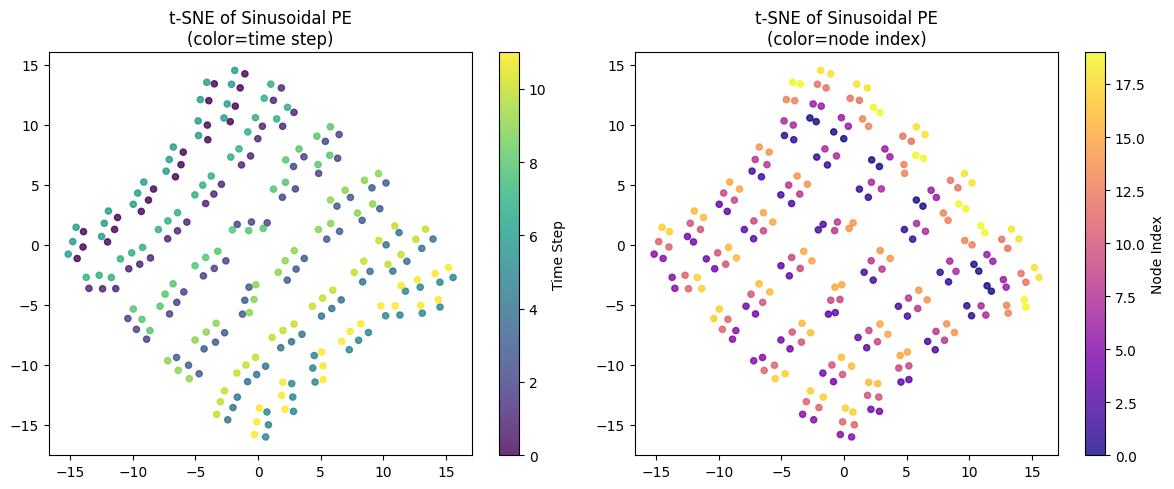

Observation: The sinusoidal PE creates smooth gradients in embedding space,
allowing models to interpolate positions and generalize to unseen lengths.


In [44]:
# Section 8b: t-SNE of sinusoidal PE to show clustering by position
# Flatten PE: each (t,n) pair becomes a sample with D features
pe_flat = pe_demo.reshape(-1, D_demo)  # (T*N, D)
labels_t = np.repeat(np.arange(T_demo), N_demo)  # temporal labels
labels_n = np.tile(np.arange(N_demo), T_demo)    # spatial labels

ts_pe = TSNE(n_components=2, random_state=42, perplexity=30)
pe_emb = ts_pe.fit_transform(pe_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by time step
sc1 = axes[0].scatter(pe_emb[:,0], pe_emb[:,1], c=labels_t, cmap='viridis', s=20, alpha=0.8)
plt.colorbar(sc1, ax=axes[0], label='Time Step')
axes[0].set_title('t-SNE of Sinusoidal PE\n(color=time step)')

# Color by node index
sc2 = axes[1].scatter(pe_emb[:,0], pe_emb[:,1], c=labels_n, cmap='plasma', s=20, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label='Node Index')
axes[1].set_title('t-SNE of Sinusoidal PE\n(color=node index)')

plt.tight_layout()
plt.show()

print('Observation: The sinusoidal PE creates smooth gradients in embedding space,')
print('allowing models to interpolate positions and generalize to unseen lengths.')

## Section 8c: Full Dataset Sinusoidal PE Visualization

Now let's compute and visualize the sinusoidal positional encoding for the **complete PEMS08 dataset** with all 170 nodes (instead of the 20-node demo subset above).

Computing sinusoidal PE for full dataset: T=12, N=170, D=32
Full PE shape: (12, 170, 32) (T, N, D)


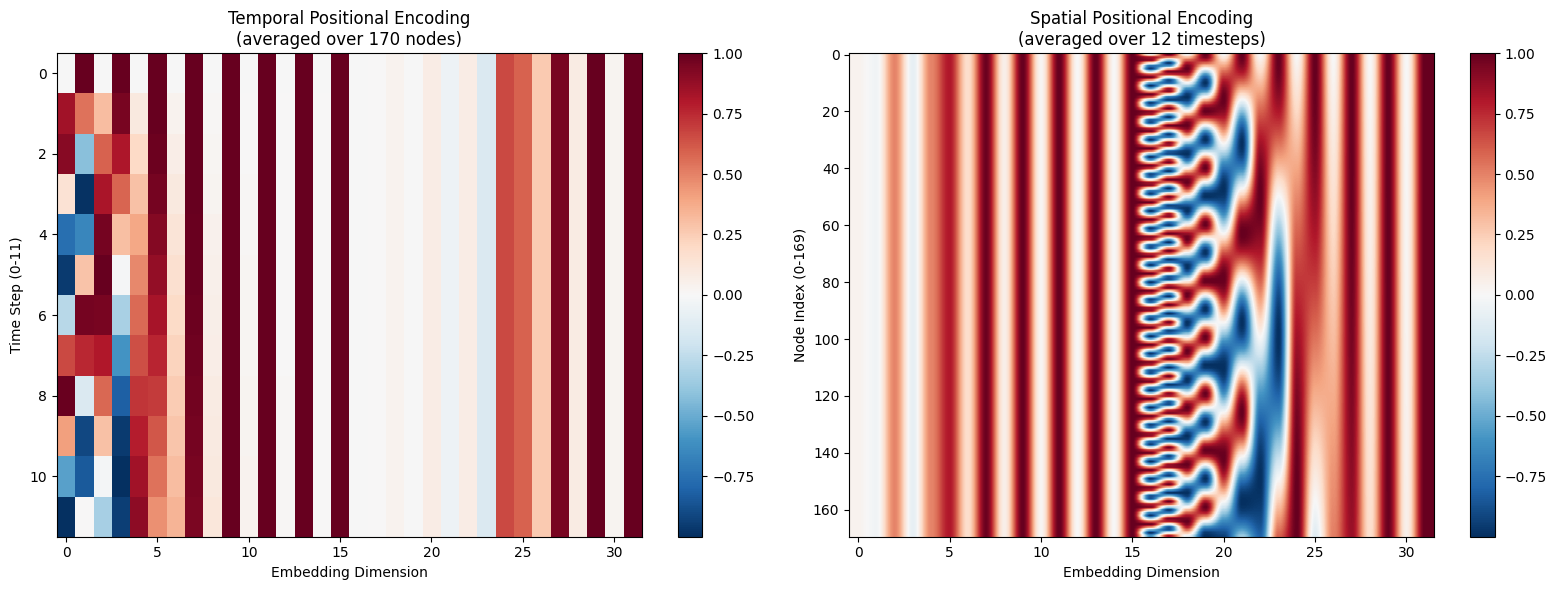

In [47]:
# Section 8c: Full dataset PE — compute for actual PEMS08 dimensions
# PEMS08 has 170 nodes, window=12 timesteps
T_full = WINDOW  # 12 timesteps
N_full = x.shape[2]  # 170 nodes (from actual data)
D_full = 32  # larger embedding dimension for full dataset

print(f'Computing sinusoidal PE for full dataset: T={T_full}, N={N_full}, D={D_full}')
pe_full = compute_sinusoidal_pe(T_full, N_full, D_full)
print(f'Full PE shape: {pe_full.shape} (T, N, D)')

# Visualize the PE heatmaps for full dataset
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temporal PE (average over all 170 nodes)
temporal_pe_full = pe_full.mean(axis=1)  # (12, 32)
im1 = axes[0].imshow(temporal_pe_full, aspect='auto', cmap='RdBu_r')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Time Step (0-11)')
axes[0].set_title(f'Temporal Positional Encoding\n(averaged over {N_full} nodes)')
plt.colorbar(im1, ax=axes[0])

# Spatial PE (average over 12 timesteps) — all 170 nodes
spatial_pe_full = pe_full.mean(axis=0)  # (170, 32)
im2 = axes[1].imshow(spatial_pe_full, aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel(f'Node Index (0-{N_full-1})')
axes[1].set_title(f'Spatial Positional Encoding\n(averaged over {T_full} timesteps)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

t-SNE input shape: (2040, 32) (T*N samples, D features)
Node indices range: 0 to 169


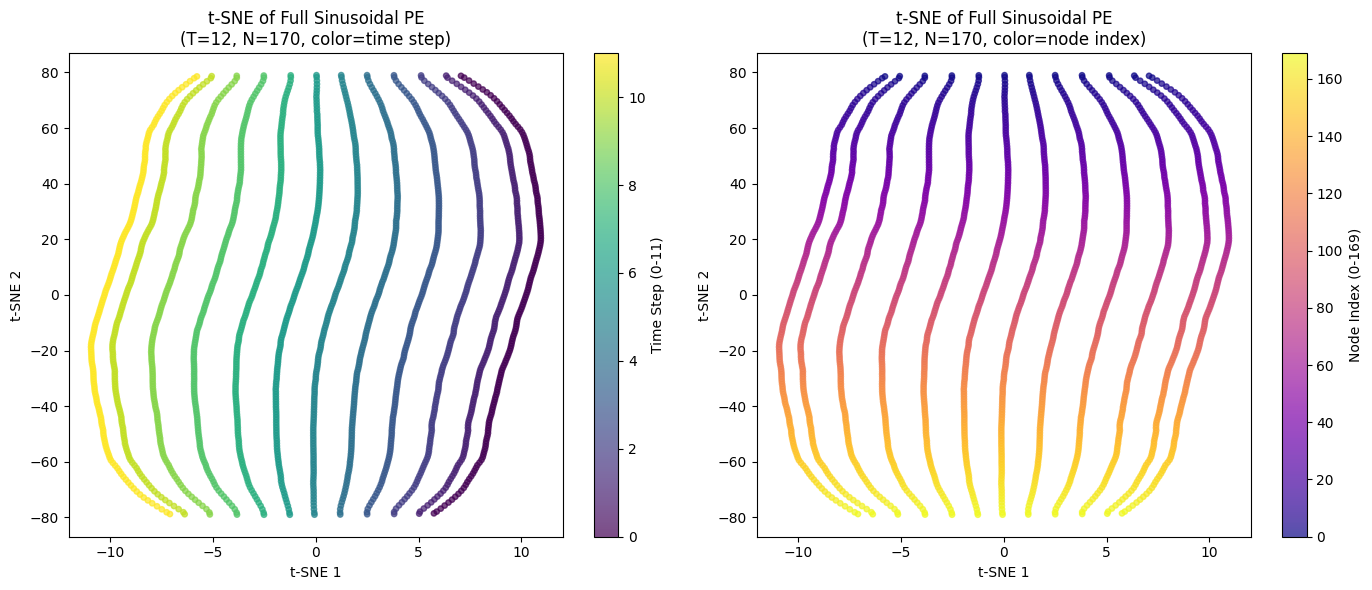


Note: With 170 nodes, the colorbar now correctly shows 0-169


In [48]:
# Section 8d: t-SNE on full dataset PE (subsampled for efficiency)
# Full dataset has 12 * 170 = 2040 points — manageable for t-SNE

pe_full_flat = pe_full.reshape(-1, D_full)  # (2040, 32)
labels_t_full = np.repeat(np.arange(T_full), N_full)  # temporal labels (0-11)
labels_n_full = np.tile(np.arange(N_full), T_full)    # spatial labels (0-169)

print(f't-SNE input shape: {pe_full_flat.shape} (T*N samples, D features)')
print(f'Node indices range: {labels_n_full.min()} to {labels_n_full.max()}')

ts_pe_full = TSNE(n_components=2, random_state=42, perplexity=50)
pe_emb_full = ts_pe_full.fit_transform(pe_full_flat)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by time step (0-11)
sc1 = axes[0].scatter(pe_emb_full[:,0], pe_emb_full[:,1], c=labels_t_full, cmap='viridis', s=15, alpha=0.7)
cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label('Time Step (0-11)')
axes[0].set_title(f't-SNE of Full Sinusoidal PE\n(T={T_full}, N={N_full}, color=time step)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# Color by node index (0-169)
sc2 = axes[1].scatter(pe_emb_full[:,0], pe_emb_full[:,1], c=labels_n_full, cmap='plasma', s=15, alpha=0.7)
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label(f'Node Index (0-{N_full-1})')
axes[1].set_title(f't-SNE of Full Sinusoidal PE\n(T={T_full}, N={N_full}, color=node index)')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

print(f'\nNote: With {N_full} nodes, the colorbar now correctly shows 0-{N_full-1}')

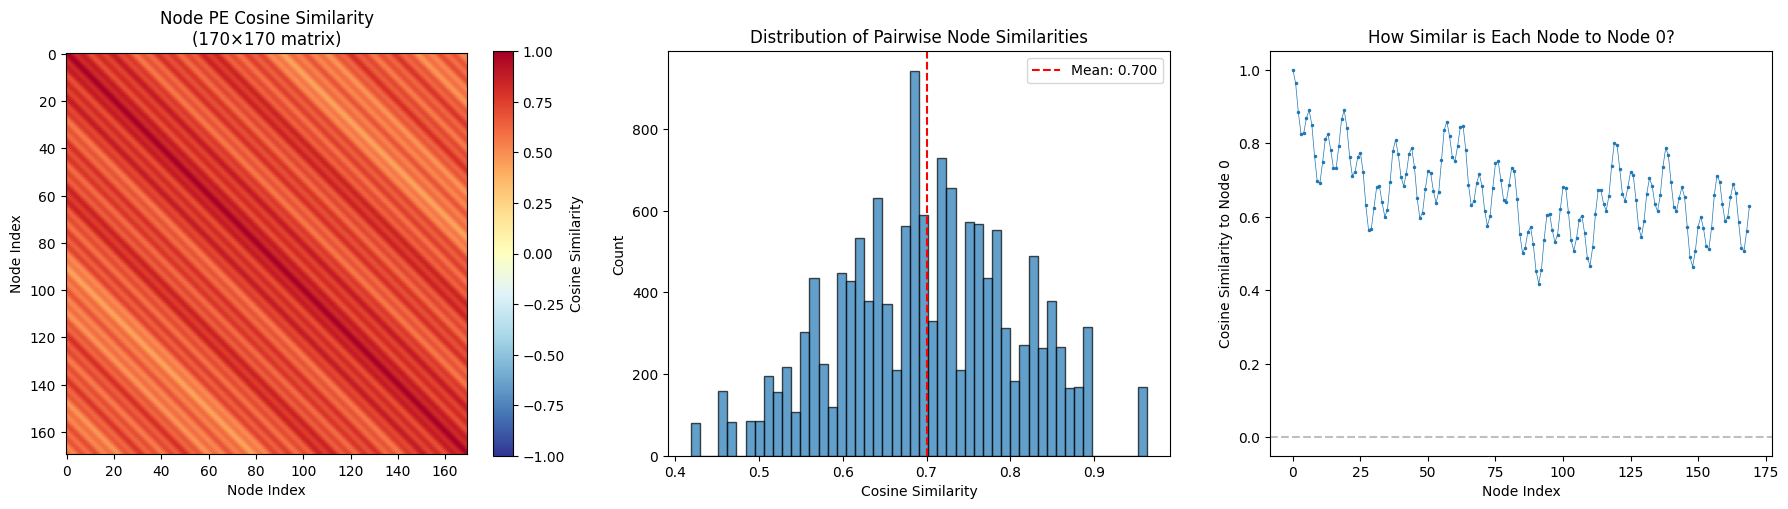

Similarity stats: min=0.418, max=0.964, mean=0.700


In [49]:
# Section 8e: Analyze PE similarity structure across all nodes
# Compute pairwise cosine similarity between node embeddings

from sklearn.metrics.pairwise import cosine_similarity

# Get spatial PE for all 170 nodes (averaged over time)
spatial_pe_nodes = pe_full.mean(axis=0)  # (170, 32) — one embedding per node

# Compute cosine similarity matrix
node_similarity = cosine_similarity(spatial_pe_nodes)  # (170, 170)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Full similarity matrix
im1 = axes[0].imshow(node_similarity, cmap='RdYlBu_r', vmin=-1, vmax=1)
axes[0].set_xlabel('Node Index')
axes[0].set_ylabel('Node Index')
axes[0].set_title(f'Node PE Cosine Similarity\n({N_full}×{N_full} matrix)')
plt.colorbar(im1, ax=axes[0], label='Cosine Similarity')

# 2. Histogram of similarities
sim_values = node_similarity[np.triu_indices(N_full, k=1)]  # upper triangle, exclude diagonal
axes[1].hist(sim_values, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(sim_values.mean(), color='red', linestyle='--', label=f'Mean: {sim_values.mean():.3f}')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Pairwise Node Similarities')
axes[1].legend()

# 3. Similarity of each node to node 0 (reference)
node0_sim = node_similarity[0, :]
axes[2].plot(node0_sim, marker='.', markersize=3, linewidth=0.5)
axes[2].set_xlabel('Node Index')
axes[2].set_ylabel('Cosine Similarity to Node 0')
axes[2].set_title('How Similar is Each Node to Node 0?')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'Similarity stats: min={sim_values.min():.3f}, max={sim_values.max():.3f}, mean={sim_values.mean():.3f}')

Mean traffic per node shape: (170,)


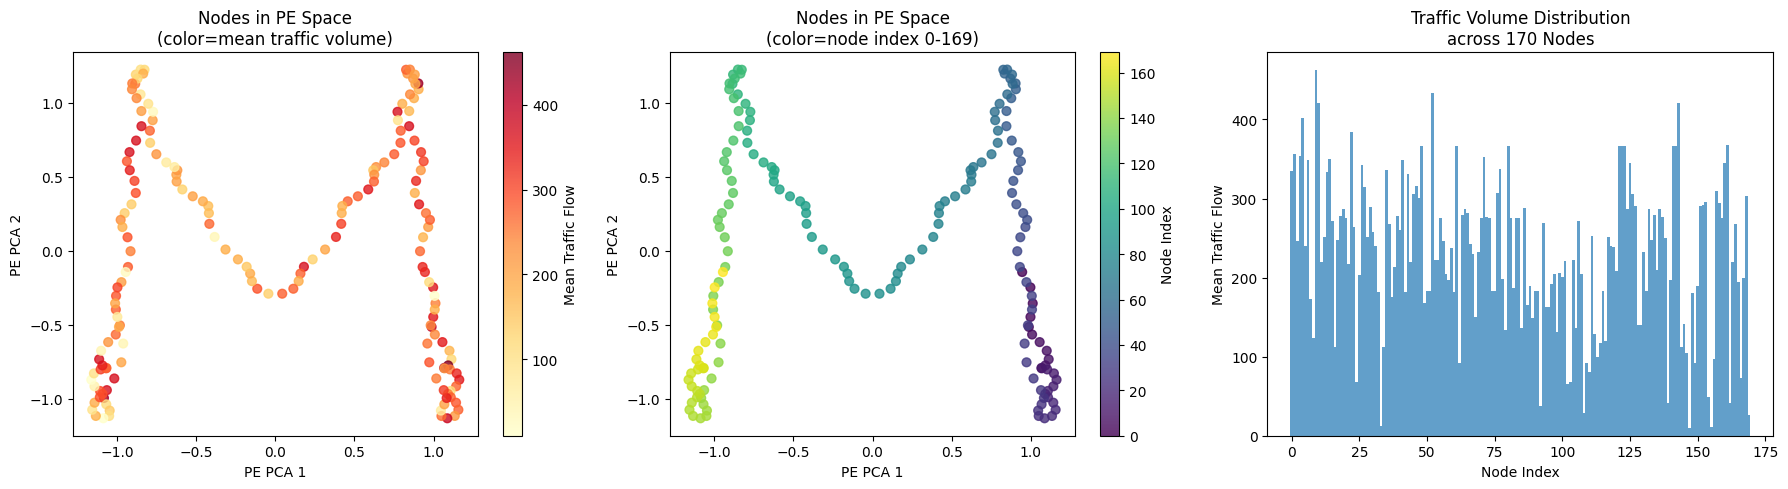


Correlation between node index and mean traffic: -0.260


In [50]:
# Section 8f: Combined visualization — PE overlaid with actual traffic patterns
# Show how sinusoidal PE relates to actual traffic data from PEMS08

# Get mean traffic value per node across all training samples
mean_traffic_per_node = x[:, :, :, 0].mean(axis=(0, 1))  # (170,)
print(f'Mean traffic per node shape: {mean_traffic_per_node.shape}')

# Create a 2D embedding of nodes using their spatial PE
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
node_pe_2d = pca.fit_transform(spatial_pe_nodes)  # (170, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Nodes in PE space, colored by traffic volume
sc1 = axes[0].scatter(node_pe_2d[:, 0], node_pe_2d[:, 1], 
                       c=mean_traffic_per_node, cmap='YlOrRd', s=40, alpha=0.8)
plt.colorbar(sc1, ax=axes[0], label='Mean Traffic Flow')
axes[0].set_xlabel('PE PCA 1')
axes[0].set_ylabel('PE PCA 2')
axes[0].set_title('Nodes in PE Space\n(color=mean traffic volume)')

# 2. Nodes colored by their index (spatial position)
sc2 = axes[1].scatter(node_pe_2d[:, 0], node_pe_2d[:, 1], 
                       c=np.arange(N_full), cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label='Node Index')
axes[1].set_xlabel('PE PCA 1')
axes[1].set_ylabel('PE PCA 2')
axes[1].set_title('Nodes in PE Space\n(color=node index 0-169)')

# 3. Traffic volume vs node index
axes[2].bar(np.arange(N_full), mean_traffic_per_node, alpha=0.7, width=1.0)
axes[2].set_xlabel('Node Index')
axes[2].set_ylabel('Mean Traffic Flow')
axes[2].set_title(f'Traffic Volume Distribution\nacross {N_full} Nodes')

plt.tight_layout()
plt.show()

# Correlation between node index and traffic
corr = np.corrcoef(np.arange(N_full), mean_traffic_per_node)[0,1]
print(f'\nCorrelation between node index and mean traffic: {corr:.3f}')

Combined features shape: (5000, 3)


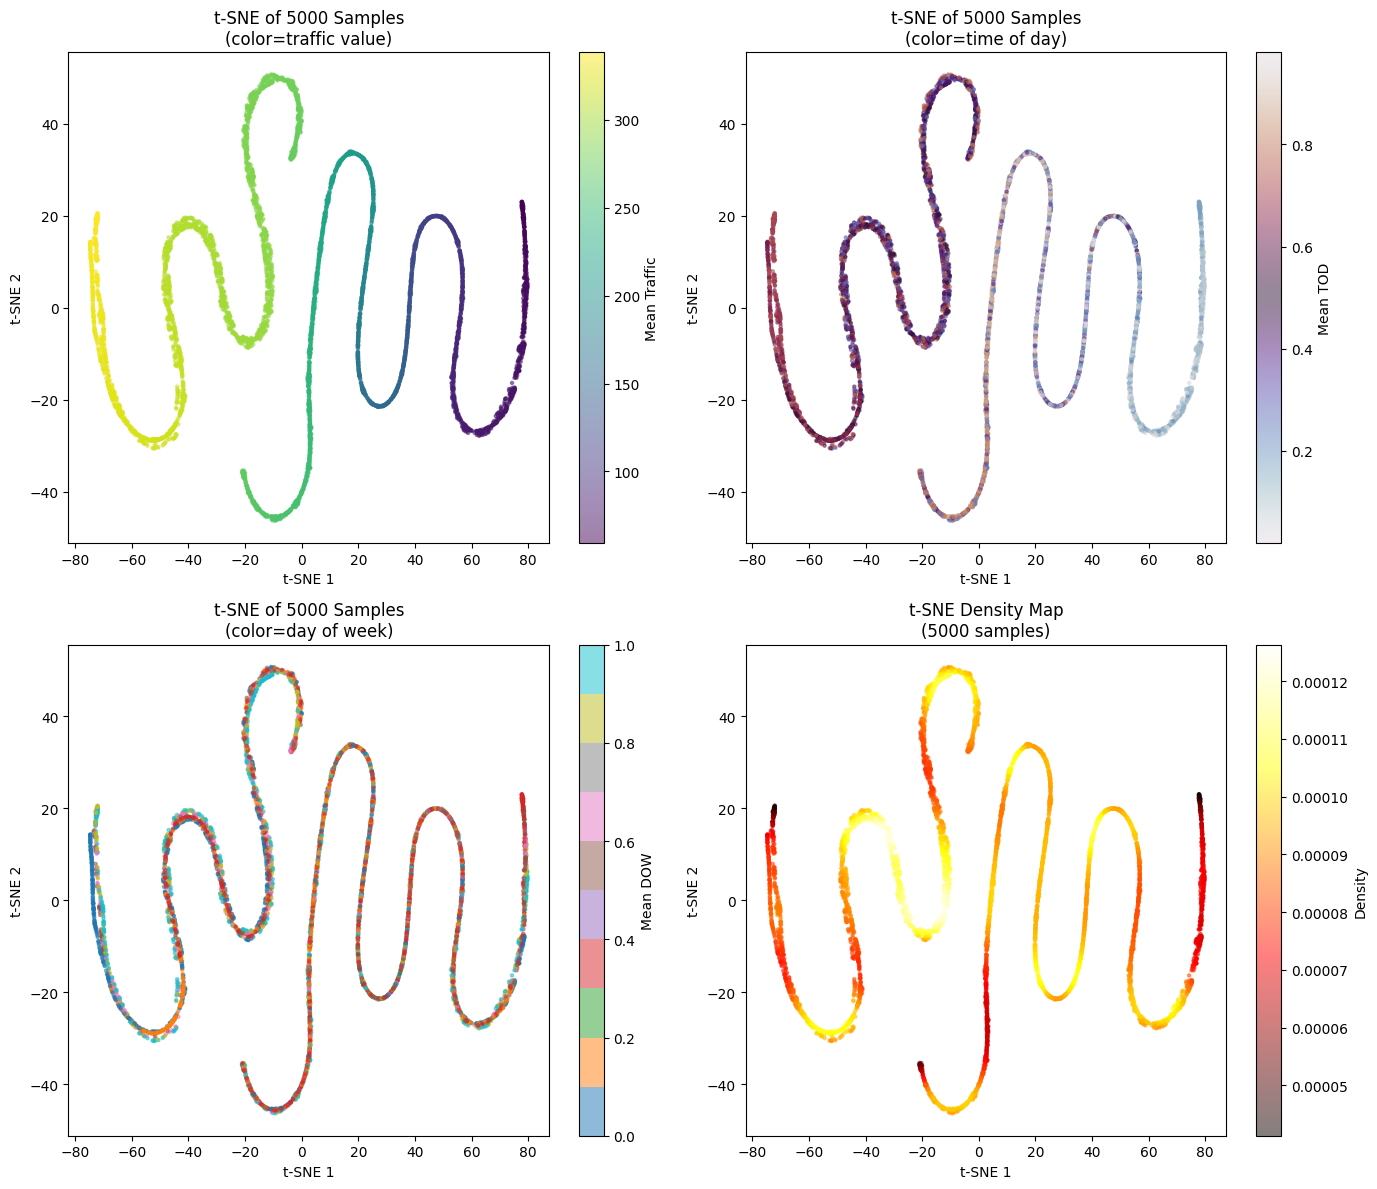


Analysis complete on 5000 samples with 170 nodes each


In [51]:
# Section 8g: Full t-SNE combining real data features with PE
# Merge actual traffic data embeddings with positional embeddings

# Take a larger sample for comprehensive analysis
n_samples = 5000
sample_full = x[:n_samples]

# Compute features: mean traffic, TOD, DOW per sample (aggregated over window and nodes)
traffic_feat = sample_full[:, :, :, 0].mean(axis=(1, 2))  # (5000,)
tod_feat = sample_full[:, :, :, 1].mean(axis=(1, 2))      # (5000,)
dow_feat = sample_full[:, :, :, 2].mean(axis=(1, 2))      # (5000,)

# Stack all features
all_features = np.stack([traffic_feat, tod_feat, dow_feat], axis=1)  # (5000, 3)
print(f'Combined features shape: {all_features.shape}')

# t-SNE on combined features
ts_full_data = TSNE(n_components=2, random_state=42, perplexity=50)
full_emb = ts_full_data.fit_transform(all_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Color by traffic value
sc1 = axes[0,0].scatter(full_emb[:,0], full_emb[:,1], c=traffic_feat, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc1, ax=axes[0,0], label='Mean Traffic')
axes[0,0].set_title(f't-SNE of {n_samples} Samples\n(color=traffic value)')

# 2. Color by TOD
sc2 = axes[0,1].scatter(full_emb[:,0], full_emb[:,1], c=tod_feat, cmap='twilight', s=5, alpha=0.5)
plt.colorbar(sc2, ax=axes[0,1], label='Mean TOD')
axes[0,1].set_title(f't-SNE of {n_samples} Samples\n(color=time of day)')

# 3. Color by DOW
sc3 = axes[1,0].scatter(full_emb[:,0], full_emb[:,1], c=dow_feat, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(sc3, ax=axes[1,0], label='Mean DOW')
axes[1,0].set_title(f't-SNE of {n_samples} Samples\n(color=day of week)')

# 4. Density plot
from scipy.stats import gaussian_kde
xy = np.vstack([full_emb[:,0], full_emb[:,1]])
density = gaussian_kde(xy)(xy)
sc4 = axes[1,1].scatter(full_emb[:,0], full_emb[:,1], c=density, cmap='hot', s=5, alpha=0.5)
plt.colorbar(sc4, ax=axes[1,1], label='Density')
axes[1,1].set_title(f't-SNE Density Map\n({n_samples} samples)')

for ax in axes.flat:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

print(f'\nAnalysis complete on {n_samples} samples with {N_full} nodes each')

## Section 9: Using `meta.npz` for Pretraining & Downstream Tasks

The `meta.npz` file stores preprocessing configuration, enabling:

### 1. **Reproducibility**
- Exact same `window_size`, `horizon`, and `channels` for train/val/test consistency
- Track whether `patch` positional encoding was used

### 2. **Pretraining Setup**
```python
# Load meta to configure your model
meta = np.load('data/PEMS08_Flow_POS/meta.npz', allow_pickle=True)
window_size = int(meta['window_size'])
horizon = int(meta['horizon'])
n_channels = int(meta['channels'])
use_patch_pe = bool(meta['patch'])
```

### 3. **Transfer Learning Workflow**
1. **Pretrain** on source dataset (e.g., PEMS08_Flow_POS)
2. **Load meta** from source to match input dimensions
3. **Fine-tune** on target dataset with same preprocessing
4. Ensure target data uses identical `window_size` and `channels`

### 4. **Multi-Task Learning**
Train shared encoder on Flow, Speed, Occupancy simultaneously:
- All share same TOD/DOW embeddings
- Only the value channel (index 0) differs
- Meta ensures consistent windowing across tasks

In [45]:
# Section 9a: Practical example — loading meta for model configuration
from pathlib import Path

# List all available POS datasets
pos_dirs = list(OUT_ROOT.glob('*_POS'))
print('Available preprocessed datasets with positional embeddings:')
for d in sorted(pos_dirs):
    meta_path = d / 'meta.npz'
    if meta_path.exists():
        m = np.load(meta_path, allow_pickle=True)
        print(f'  {d.name}:')
        print(f'    window={m["window_size"]}, horizon={m["horizon"]}, channels={m["channels"]}, patch={m["patch"]}')

# Example: Configure a PyTorch model using meta
print('\n--- Example PyTorch Model Configuration ---')
meta = np.load(OUT_ROOT / 'PEMS08_Flow_POS' / 'meta.npz', allow_pickle=True)

config = {
    'input_window': int(meta['window_size']),
    'output_horizon': int(meta['horizon']),
    'input_channels': int(meta['channels']),  # [value, tod, dow]
    'output_channels': 1,  # predict value only
    'use_patch_pe': bool(meta['patch']),
    'patch_embed_dim': meta['patch_D'] if meta['patch'] else None
}

print('Model config from meta.npz:')
for k, v in config.items():
    print(f'  {k}: {v}')

Available preprocessed datasets with positional embeddings:
  PEMS04_Flow_POS:
    window=12, horizon=12, channels=3, patch=False
  PEMS04_Occupancy_POS:
    window=12, horizon=12, channels=3, patch=False
  PEMS04_Speed_POS:
    window=12, horizon=12, channels=3, patch=False
  PEMS08_Flow_POS:
    window=12, horizon=12, channels=3, patch=False
  PEMS08_Occupancy_POS:
    window=12, horizon=12, channels=3, patch=False
  PEMS08_Speed_POS:
    window=12, horizon=12, channels=3, patch=False

--- Example PyTorch Model Configuration ---
Model config from meta.npz:
  input_window: 12
  output_horizon: 12
  input_channels: 3
  output_channels: 1
  use_patch_pe: False
  patch_embed_dim: None


In [46]:
# Section 9b: Pretraining data loader example
import torch
from torch.utils.data import Dataset, DataLoader

class PEMSDataset(Dataset):
    """PyTorch Dataset for preprocessed PEMS data with positional embeddings."""
    def __init__(self, data_dir, split='train'):
        npz = np.load(Path(data_dir) / f'{split}.npz')
        self.x = npz['x'].astype(np.float32)  # (N, T, nodes, C)
        self.y = npz['y'].astype(np.float32)  # (N, T, nodes, 1)
        
        # Load meta for reference
        meta = np.load(Path(data_dir) / 'meta.npz', allow_pickle=True)
        self.window = int(meta['window_size'])
        self.horizon = int(meta['horizon'])
        self.channels = int(meta['channels'])
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        # Returns: input (T, N, C), target (T, N, 1)
        return torch.from_numpy(self.x[idx]), torch.from_numpy(self.y[idx])

# Demo: create dataset and loader
demo_ds = PEMSDataset(OUT_ROOT / 'PEMS08_Flow_POS', split='train')
demo_loader = DataLoader(demo_ds, batch_size=32, shuffle=True)

# Get a batch
batch_x, batch_y = next(iter(demo_loader))
print(f'Batch x shape: {batch_x.shape}')  # (batch, window, nodes, channels)
print(f'Batch y shape: {batch_y.shape}')  # (batch, horizon, nodes, 1)
print(f'Dataset meta: window={demo_ds.window}, horizon={demo_ds.horizon}, channels={demo_ds.channels}')

Batch x shape: torch.Size([32, 12, 170, 3])
Batch y shape: torch.Size([32, 12, 170, 1])
Dataset meta: window=12, horizon=12, channels=3


## Section 10: Summary & Key Takeaways

### Data Format
| Array | Shape | Description |
|-------|-------|-------------|
| `x` | `(N, 12, nodes, 3)` | Input: [value, TOD_scaled, DOW_scaled] |
| `y` | `(N, 12, nodes, 1)` | Target: value only |

### Positional Embeddings Used
1. **TOD (Time-of-Day)**: `[0, 287] → [0, 1]` — captures daily periodicity
2. **DOW (Day-of-Week)**: `[0, 6] → [0, 1]` — captures weekly periodicity
3. **Sinusoidal PE** (optional): 2D encoding for transformers

### Downstream Applications
- **Traffic Flow Prediction**: Use Flow folders
- **Speed Prediction**: Use Speed folders  
- **Occupancy Prediction**: Use Occupancy folders
- **Multi-task Learning**: Combine all three with shared temporal encoder

### Files Generated
```
data/PEMS08_Flow_POS/
├── train.npz    # Training split (~60%)
├── val.npz      # Validation split (~20%)
├── test.npz     # Test split (~20%)
└── meta.npz     # Preprocessing config for reproducibility
```